In [2]:
import zipfile
import os

# Define the path to the zip file
zip_file_path = '/content/archive.zip'
# Define the directory where the contents will be extracted
extract_dir = '/content/'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}'")

# Verify that the CSV file exists after extraction
expected_csv_path = os.path.join(extract_dir, 'SampleSuperstore.csv')
if os.path.exists(expected_csv_path):
    print(f"'{os.path.basename(expected_csv_path)}' found at '{expected_csv_path}'")
else:
    print(f"Error: '{os.path.basename(expected_csv_path)}' not found after extraction.")

'/content/archive.zip' unzipped to '/content/'
Error: 'SampleSuperstore.csv' not found after extraction.


Dataset Shape: (9994, 21)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

First 5 Rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Clair

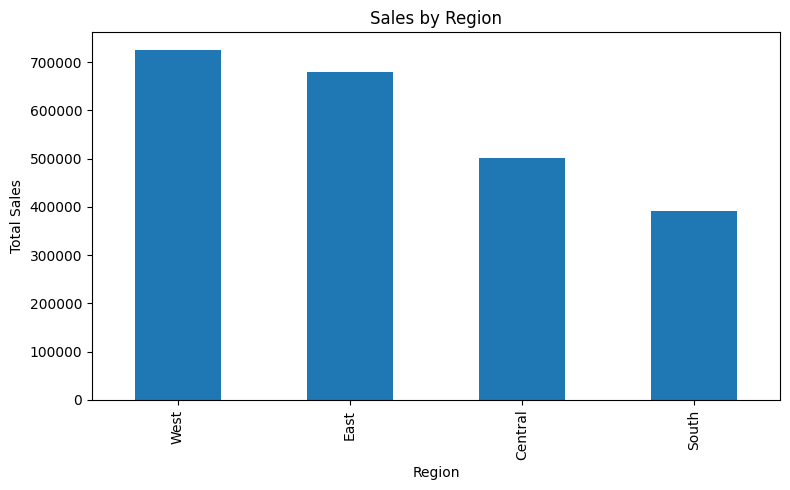

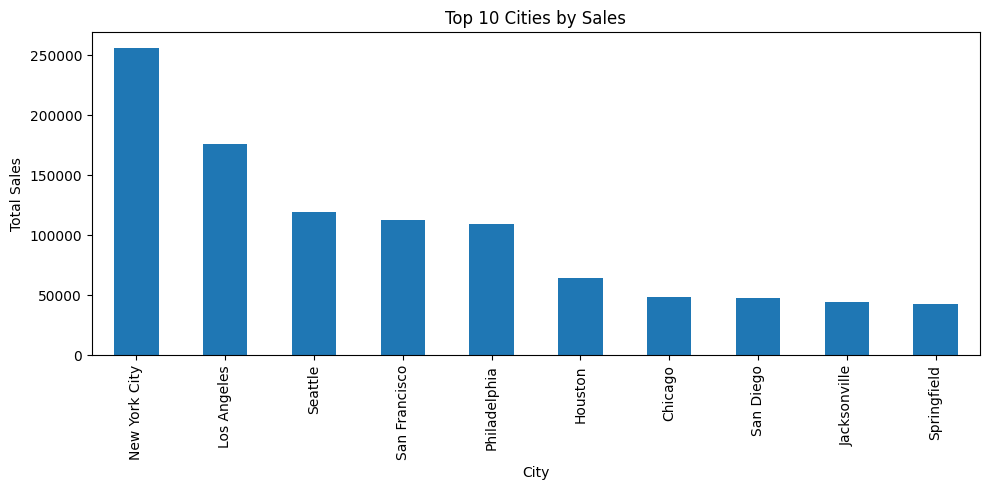

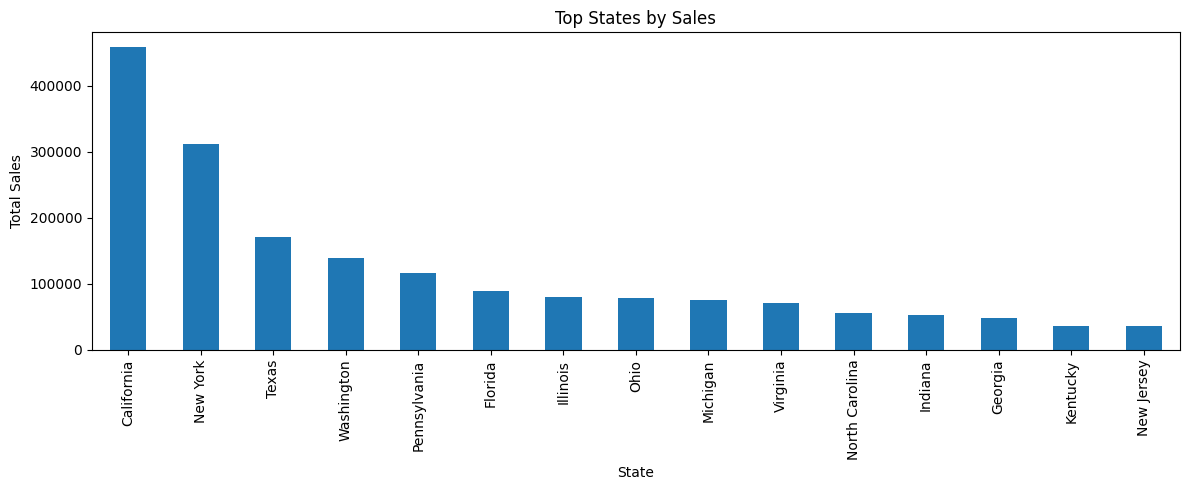

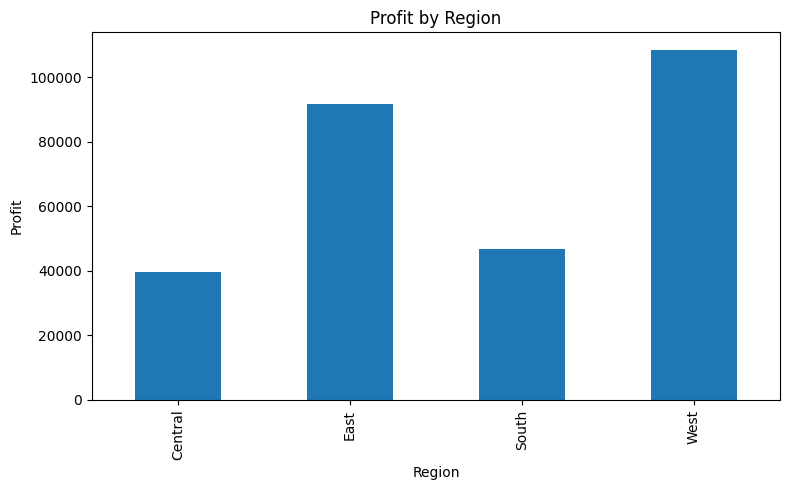


Business Expansion Insights:
1. Regions with highest sales indicate strong demand.
2. High sales but relatively lower profit regions may need optimization.
3. Top-performing cities are potential candidates for expansion.
4. Low-sales regions may require additional marketing efforts.


In [5]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')

# Display Basic Information
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# -------------------------------
# Sales by Region
# -------------------------------
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Total Sales")
plt.xlabel("Region")
plt.tight_layout()
plt.savefig("sales_by_region.png")
plt.show()

# -------------------------------
# Top 10 Cities by Sales
# -------------------------------
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
city_sales.plot(kind='bar')
plt.title("Top 10 Cities by Sales")
plt.ylabel("Total Sales")
plt.xlabel("City")
plt.tight_layout()
plt.savefig("top_cities_sales.png")
plt.show()

# -------------------------------
# Sales by State
# -------------------------------
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,5))
state_sales.plot(kind='bar')
plt.title("Top States by Sales")
plt.ylabel("Total Sales")
plt.xlabel("State")
plt.tight_layout()
plt.savefig("sales_by_state.png")
plt.show()

# -------------------------------
# Profit by Region
# -------------------------------
region_profit = df.groupby("Region")["Profit"].sum()

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')
plt.title("Profit by Region")
plt.ylabel("Profit")
plt.xlabel("Region")
plt.tight_layout()
plt.savefig("profit_by_region.png")
plt.show()

# -------------------------------
# Business Expansion Insights
# -------------------------------
print("\nBusiness Expansion Insights:")
print("1. Regions with highest sales indicate strong demand.")
print("2. High sales but relatively lower profit regions may need optimization.")
print("3. Top-performing cities are potential candidates for expansion.")
print("4. Low-sales regions may require additional marketing efforts.")